In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset("titanic")

In [3]:
titanic.sample(20)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
331,0,1,male,45.5,0,0,28.5000,S,First,man,True,C,Southampton,no,True
631,0,3,male,51.0,0,0,7.0542,S,Third,man,True,NaN,Southampton,no,True
799,0,3,female,30.0,1,1,24.1500,S,Third,woman,False,NaN,Southampton,no,False
215,1,1,female,31.0,1,0,113.2750,C,First,woman,False,D,Cherbourg,yes,False
480,0,3,male,9.0,5,2,46.9000,S,Third,child,False,NaN,Southampton,no,False
427,1,2,female,19.0,0,0,26.0000,S,Second,woman,False,NaN,Southampton,yes,True
130,0,3,male,33.0,0,0,7.8958,C,Third,man,True,NaN,Cherbourg,no,True
435,1,1,female,14.0,1,2,120.0000,S,First,child,False,B,Southampton,yes,False
634,0,3,female,9.0,3,2,27.9000,S,Third,child,False,NaN,Southampton,no,False
744,1,3,male,31.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,yes,True


In [4]:
titanic.info()
titanic.describe(include="all").T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
titanic = titanic.dropna(subset=["age"])

In [6]:
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     714 non-null    int64   
 1   pclass       714 non-null    int64   
 2   sex          714 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        714 non-null    int64   
 5   parch        714 non-null    int64   
 6   fare         714 non-null    float64 
 7   embarked     714 non-null    object  
 8   class        714 non-null    category
 9   who          714 non-null    object  
 10  adult_male   714 non-null    bool    
 11  embark_town  712 non-null    object  
 12  alive        714 non-null    object  
 13  alone        714 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 69.2+ KB


In [7]:
titanic = titanic.drop(columns=["deck"])

In [8]:
print(titanic.groupby(["sex", "who"])["survived"].mean())
print(titanic.groupby(["pclass", "who"])["survived"].mean())

sex     who  
female  child    0.651163
        woman    0.775229
male    child    0.525000
        man      0.174334
Name: survived, dtype: float64
pclass  who  
1       child    0.833333
        man      0.377551
        woman    0.975610
2       child    1.000000
        man      0.066667
        woman    0.906250
3       child    0.431034
        man      0.128889
        woman    0.430556
Name: survived, dtype: float64


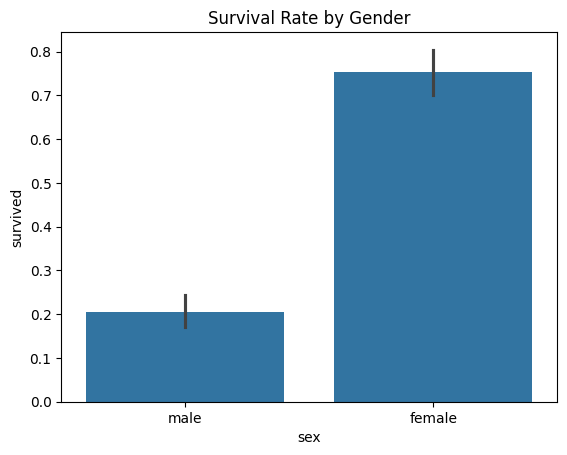

In [10]:
sns.barplot(x="sex", y="survived", data=titanic)
plt.title("Survival Rate by Gender")
plt.show()

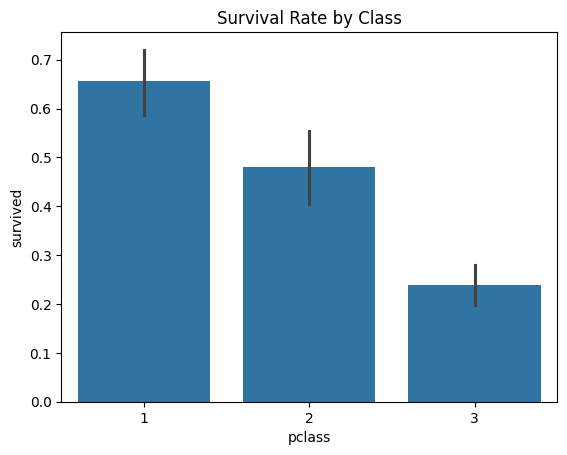

In [14]:
sns.barplot(x="pclass", y="survived", data=titanic)
plt.title("Survival Rate by Class")
plt.show()

In [58]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

titanic_enc = titanic.copy()
titanic_enc["sex"] = titanic_enc["sex"].astype("category").cat.codes
x = np.asanyarray(titanic_enc[["sex", "pclass"]])
y = np.asarray(titanic_enc["survived"])

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=41)

In [59]:
model = LogisticRegression()
model.fit(train_x, train_y)
pred_y = model.predict(test_x)

In [60]:
from sklearn.metrics import accuracy_score

In [61]:
accuracy_score(pred_y, test_y)

0.7762237762237763

In [ ]:
test_x

In [74]:
model.predict([[1,1]])

array([0])

In [70]:
titanic_enc

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,1,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,0,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,0,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,0,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,1,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,0,3,0,39.0,0,5,29.1250,Q,Third,woman,False,Queenstown,no,False
886,0,2,1,27.0,0,0,13.0000,S,Second,man,True,Southampton,no,True
887,1,1,0,19.0,0,0,30.0000,S,First,woman,False,Southampton,yes,True
889,1,1,1,26.0,0,0,30.0000,C,First,man,True,Cherbourg,yes,True
